In [1]:
# Import the packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", None)

# Load the feature engineered Data for France 2024

In [2]:
df_2024 = pd.read_csv("../data/processed/EU/2024_FR_cleaned.csv")
display(df_2024.head())

,Vehicle,Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,Electric range (km),r,Equipment_Mass,IT_28,IT_29,IT_32,IT_33,IT_37,IT_none
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS72VR21BAI0 - 1T - E1*2001/116*0211*63,1807.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,3,132.0,0,1,0,0,0,0
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1757.0,134.0,diesel,M,1968.0,90.0,0.0,1.00,5.1,0.0,1,125.0,0,1,0,0,0,0
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAI0 - 1T - E1*2001/116*0211*65,1787.0,137.0,diesel,M,1968.0,110.0,0.0,1.00,5.2,0.0,1,156.0,0,1,0,0,0,0
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAIM - 1T - E1*2001/116*0211*65,1791.0,137.0,diesel,M,1968.0,110.0,0.0,1.68,5.2,0.0,1,160.0,1,1,0,0,0,0
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1799.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,1,124.0,0,1,0,0,0,0


Let's drop the **r** column:

In [3]:
df_2024.drop("r", inplace=True, axis=1)

## Now, let's reverse a mistake we have made earlier:
Set the Zeros in ["Electric range (km)", "z (Wh/km)", "Erwltp (g/km)", "Fuel consumption"] columns to NaN

In [4]:
cols = ["Electric range (km)", "z (Wh/km)", "Erwltp (g/km)"]

# Set the values that are 0 in these columns to NaN
df_2024[cols] = df_2024[cols].replace(0, np.nan)

# Check: the first few lines and NaN values
print(df_2024[cols].head())
print("\nNaN counts:\n", df_2024[cols].isna().sum())

   Electric range (km)  z (Wh/km)  Erwltp (g/km)
0                  NaN        NaN           1.00
1                  NaN        NaN           1.00
2                  NaN        NaN           1.00
3                  NaN        NaN           1.68
4                  NaN        NaN           1.00

NaN counts:
 Electric range (km)    81512
z (Wh/km)              81512
Erwltp (g/km)          58621
dtype: int64


## Another mistake to be reversed:
If **"Electric range (km)", "z (Wh/km)"** fields are only relevant for certain fuel types and we’re already entering **Ft** into the model, it makes sense to remove these columns entirely:

In [5]:
cols_to_drop = ["Electric range (km)", "z (Wh/km)"]
df_2024.drop(cols_to_drop, axis=1, inplace=True)

# Let's see the distributions of the numeric columns:

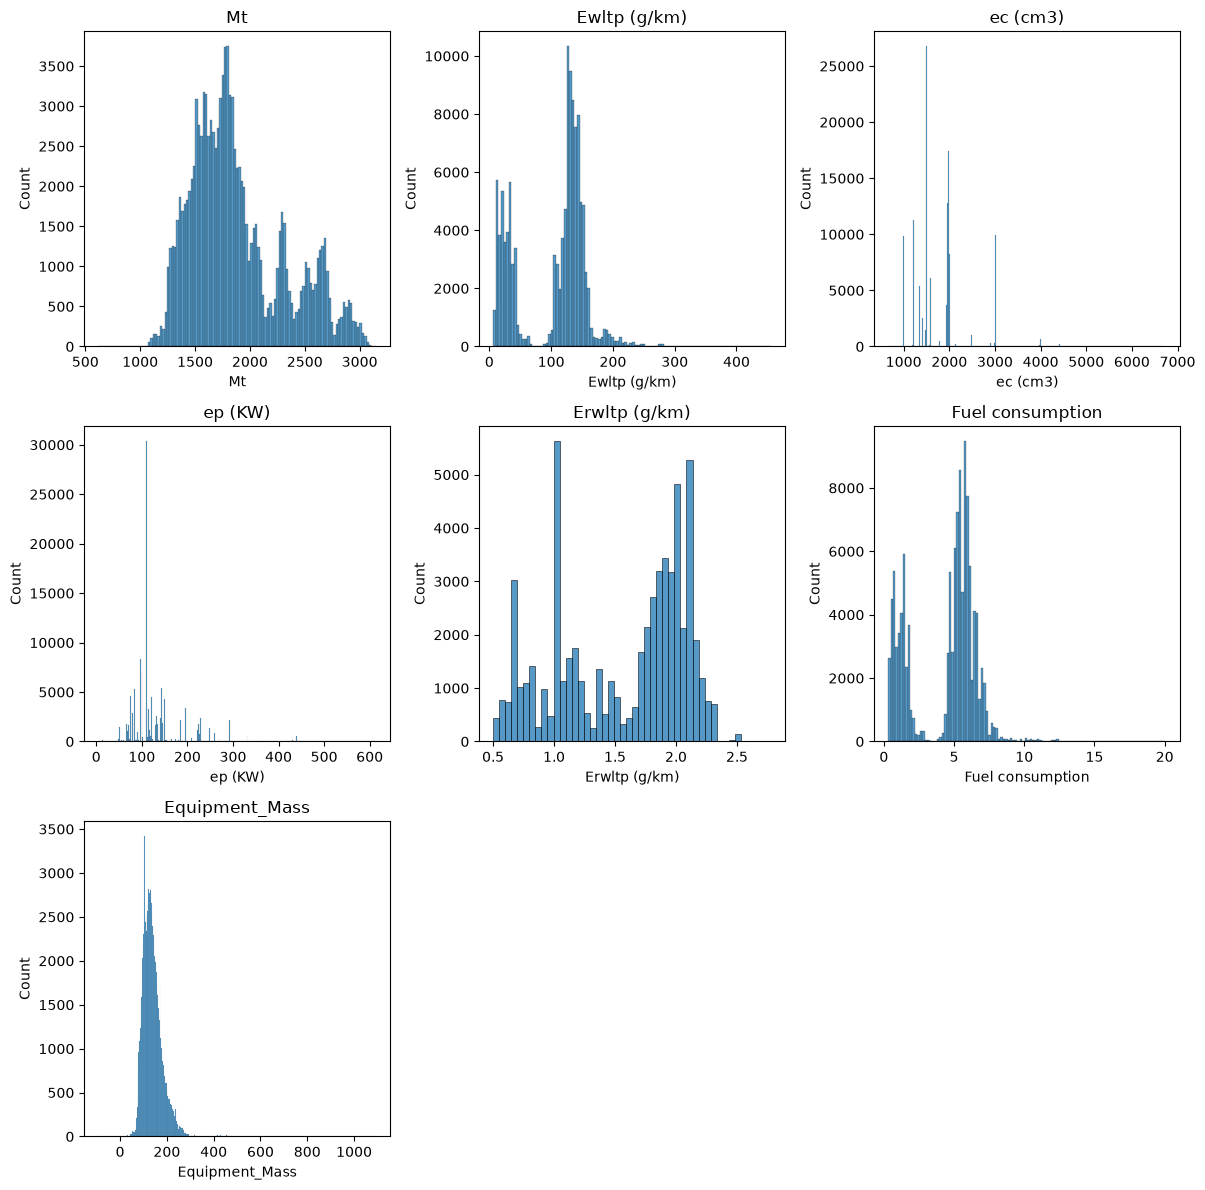

In [6]:
def dist_graphs():
    num_cols = [
        "Mt", "Ewltp (g/km)", "ec (cm3)", "ep (KW)", "Erwltp (g/km)",
        "Fuel consumption", "Equipment_Mass"]
    
    fig = plt.figure(figsize = (12, 12))
    
    for idx, col in enumerate(num_cols, start=1):
        ax = fig.add_subplot(3, 3, idx)  # 3x3 grid, idx. cell
        sns.histplot(x=df_2024[col], ax=ax)
        ax.set_title(col)
    
    plt.tight_layout()
    plt.show()
dist_graphs()

# We need to evaluate this based on Fuel types:
# Let's remember the Ft and Fm distributions 
## Fm modes:
- **"M":** Mono-Fuel / Single-Fuel
- **"H":** Hybrid / Standard Hybrid
- **"E":** Battery Electric Vehicle - BEV / Fully Electric
- **"B":** Bi-Fuel / Dual-Fuel
- **"P":** PHEV (Plug-in Hybrid Electric Vehicle)
- **"F":** Flex-Fuel / Flexible Fuel


In [7]:
print("Ft: Fuel type distribution")
print(df_2024["Ft"].value_counts()/len(df_2024)*100)
print("\n*************\n")
print("Fm: Fuel mode distribution")
print(df_2024["Fm"].value_counts()/len(df_2024)*100)

Ft: Fuel type distribution
Ft
petrol             43.726755
petrol/electric    29.221813
diesel             23.289496
diesel/electric     2.498744
e85                 0.676830
lpg                 0.586363
Name: count, dtype: float64

*************

Fm: Fuel mode distribution
Fm
M    41.805998
P    31.720556
H    25.866979
B     0.586363
F     0.020104
Name: count, dtype: float64


### Let's define our cutoff at diesel, and drop diesel/electric, e85, and lpg data since they are very low.

In [8]:
allowed_fuel_types = ["petrol", "petrol/electric", "diesel"]
df_2024 = df_2024[df_2024["Ft"].isin(allowed_fuel_types)].copy()

print(" New Ft distribution:\n", df_2024["Ft"].value_counts(normalize=True)*100)
print("\n*************\n")
print("New Fm (Fuel mode) distribution")
print(df_2024["Fm"].value_counts()/len(df_2024)*100)

 New Ft distribution:
 Ft
petrol             45.436030
petrol/electric    30.364091
diesel             24.199880
Name: proportion, dtype: float64

*************

New Fm (Fuel mode) distribution
Fm
M    43.440190
P    30.364091
H    26.195719
Name: count, dtype: float64


In [9]:
def summary():
    
    my_cols = [
        "Erwltp (g/km)",
        "Fuel consumption",
        "Equipment_Mass"
    ]
    
    preprocessing_summary = pd.DataFrame({
        "dtype": df_2024[my_cols].dtypes.astype(str),
        "missing_count": df_2024[my_cols].isna().sum(),
        "missing_pct": (df_2024[my_cols].isna().mean() * 100).round(2),
        "zero_count": (df_2024[my_cols] == 0).sum(),
        "zero_pct": ((df_2024[my_cols] == 0).mean() * 100).round(2),
        "unique_values": df_2024[my_cols].nunique(),
        "min": df_2024[my_cols].min(),
        "q1": df_2024[my_cols].quantile(0.25),
        "median": df_2024[my_cols].median(),
        "q3": df_2024[my_cols].quantile(0.75),
        "max": df_2024[my_cols].max()
    }).round(2)
    
    display(preprocessing_summary)

summary()

,dtype,missing_count,missing_pct,zero_count,zero_pct,unique_values,min,q1,median,q3,max
Erwltp (g/km),float64,55490,48.3,0,0.0,183,0.5,1.0,1.76,2.0,2.78
Fuel consumption,float64,0,0.0,0,0.0,154,0.3,1.7,5.30,5.9,20.10
Equipment_Mass,float64,0,0.0,0,0.0,529,-94.0,109.0,132.00,159.0,1094.00


We seem to have negative values in the Equipment_Mass column. 
This is suspicious, because we'd expect Mt (test mass) to be greater than the mass of the naked vehicle M (kg). 
Negative equipment mass is impossible.
Let's see how these lines look:

In [10]:
df_2024.loc[df_2024["Equipment_Mass"] < 0].sort_values("Equipment_Mass")

,Vehicle,Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),Erwltp (g/km),Fuel consumption,Equipment_Mass,IT_28,IT_29,IT_32,IT_33,IT_37,IT_none
3717,VOLKSWAGEN - TIGUAN - ACDTSBX0 - FD7FD7GC009L7N5NVR24BI1AA0M1ISO - 5N - E1*2001/116*0450*70,1644.0,150.0,diesel,M,1968.0,110.0,1.00,5.7,-94.0,0,1,0,0,0,0
3720,VOLKSWAGEN - TIGUAN - ACDTSBX0 - FD7FD7GC009L7N5NVR24BI1AANM1ISO - 5N - E1*2001/116*0450*70,1651.0,150.0,diesel,M,1968.0,110.0,1.66,5.7,-87.0,0,1,0,0,1,0
3534,VOLKSWAGEN - TIGUAN - ACDTSBX0 - FD7FD7GC009L7N5NVR24BI1ASANM1ISO - 5N - E1*2001/116*0450*69,1667.0,149.0,diesel,M,1968.0,110.0,1.66,5.7,-72.0,0,1,0,0,1,0
62921,VOLKSWAGEN - T-ROC - DLAAX0AE2 - FM6FM6AJ0254BI1CANNI2GA0 - A1 - E13*2007/46*1845*28,1439.0,151.0,petrol,M,999.0,81.0,1.17,6.6,-57.0,0,1,0,0,0,0
12722,AUDI - A6 AVANT 55 TFSI E - ADRYAQ1 - QD7AD7DK001101B19S54BIBEM9H66FSB3 - F2 - E1*2007/46*1801*41,2104.0,33.0,petrol/electric,P,1984.0,195.0,NaN,1.4,-46.0,0,0,0,0,0,1
13401,AUDI - A6 AVANT 50 TFSI E - ADRYAQ1 - QD7AD7DK001091B18S54WEBEM8H66FSB3 - F2 - E1*2007/46*1801*45,2104.0,34.0,petrol/electric,P,1984.0,195.0,NaN,1.5,-46.0,0,0,0,0,0,1
65082,VOLKSWAGEN - T-CROSS - DUSAACX0 - FD7FD7CW0094WE1AA - C1 - E13*2007/46*1985*18,1252.0,120.0,petrol,M,999.0,85.0,NaN,5.3,-44.0,0,0,0,0,0,1
12865,AUDI - A7 55 TFSI E - SDRYAQ1 - QD7AD7DK001111B19S44WEBEM9H66FSB3 - F2 - E1*2007/46*1801*42,2104.0,33.0,petrol/electric,P,1984.0,195.0,NaN,1.4,-36.0,0,0,0,0,0,1
62928,VOLKSWAGEN - T-ROC - DTRDX0AC4 - FM6FM6C90124BI1AANNI2GA0 - A1 - E13*2007/46*1845*28,1387.0,123.0,diesel,M,1968.0,85.0,1.04,4.7,-32.0,0,1,0,0,0,0
64990,VOLKSWAGEN - T-CROSS - DLAAACX0 - FD7FD7CW0094BI1AA0I - C1 - E13*2007/46*1985*17,1277.0,142.0,petrol,M,999.0,81.0,1.13,6.2,-13.0,0,1,0,0,0,0


That's only 14 lines. 
Let's delete these lines:

In [11]:
rows_before = len(df_2024)

df_2024 = df_2024.loc[
    df_2024["Equipment_Mass"] >= 0
].copy()

rows_after = len(df_2024)

print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")
print(f"Negative Equipment_Mass remaining: {(df_2024['Equipment_Mass'] < 0).sum()}")

Rows before: 114889
Rows after: 114875
Rows removed: 14
Negative Equipment_Mass remaining: 0


Let's see the numbers again:

In [12]:
summary()

,dtype,missing_count,missing_pct,zero_count,zero_pct,unique_values,min,q1,median,q3,max
Erwltp (g/km),float64,55483,48.3,0,0.0,183,0.5,1.0,1.76,2.0,2.78
Fuel consumption,float64,0,0.0,0,0.0,154,0.3,1.7,5.30,5.9,20.10
Equipment_Mass,float64,0,0.0,0,0.0,517,3.0,109.0,132.00,159.0,1094.00


## Let's analyse our outliers:

In [13]:
def outlier_summary():
    my_numeric_cols = [
        "Erwltp (g/km)",
        "Fuel consumption",
        "Equipment_Mass"
    ]
    
    outlier_rows = []
    
    for col in my_numeric_cols:
        series = df_2024[col]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
    
        outlier_mask = (series < lower_bound) | (series > upper_bound)
    
        outlier_rows.append({
            "column": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_mask.sum(),
            "outlier_pct": round(outlier_mask.mean() * 100, 2),
            "min_outlier": series[outlier_mask].min(),
            "max_outlier": series[outlier_mask].max()
        })
    
    outlier_summary = (
        pd.DataFrame(outlier_rows)
        .set_index("column")
        .round(2)
    )
    
    display(outlier_summary)

outlier_summary()


,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,min_outlier,max_outlier
column,,,,,,,,,
Erwltp (g/km),1.0,2.0,1.0,-0.5,3.5,0,0.00,NaN,NaN
Fuel consumption,1.7,5.9,4.2,-4.6,12.2,266,0.23,12.3,20.1
Equipment_Mass,109.0,159.0,50.0,34.0,234.0,3391,2.95,3.0,1094.0


Let's clean the outliers of **Fuel consumption:**

In [14]:
# Fuel consumption Upper outlier cleanup

fc_upper_outlier = df_2024["Fuel consumption"] > 12.20

rows_before = len(df_2024)
df_2024 = df_2024.loc[~fc_upper_outlier].copy()
rows_after = len(df_2024)

print(f"Rows before FC cleaning: {rows_before}")
print(f"Rows after FC cleaning: {rows_after}")
print(f"Fuel consumption outliers removed: {rows_before - rows_after}")

# Remaining Fuel Consumption Statistics
print("\nFuel consumption stats after cleaning:")
print(df_2024["Fuel consumption"].describe())

Rows before FC cleaning: 114875
Rows after FC cleaning: 114609
Fuel consumption outliers removed: 266

Fuel consumption stats after cleaning:
count    114609.000000
mean          4.402417
std           2.240821
min           0.300000
25%           1.700000
50%           5.300000
75%           5.900000
max          12.200000
Name: Fuel consumption, dtype: float64


Next, **Erwltp (g/km)**

In [15]:
# Erwltp (g/km) Upper outlier cleanup

erwltp_upper_outlier = df_2024["Erwltp (g/km)"] > 3.5

rows_before = len(df_2024)
df_2024 = df_2024.loc[~erwltp_upper_outlier].copy()
rows_after = len(df_2024)

print(f"Rows before Erwltp cleaning: {rows_before}")
print(f"Rows after Erwltp cleaning: {rows_after}")
print(f"Erwltp outliers removed: {rows_before - rows_after}")

# Remaining Erwltp Statistics
print("\nErwltp stats after cleaning:")
print(df_2024["Erwltp (g/km)"].describe())

Rows before Erwltp cleaning: 114609
Rows after Erwltp cleaning: 114609
Erwltp outliers removed: 0

Erwltp stats after cleaning:
count    59329.000000
mean         1.550224
std          0.526505
min          0.500000
25%          1.000000
50%          1.760000
75%          2.000000
max          2.780000
Name: Erwltp (g/km), dtype: float64


Let's see the summary and the distribution graphs again:

In [16]:
outlier_summary()

,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,min_outlier,max_outlier
column,,,,,,,,,
Erwltp (g/km),1.0,2.0,1.0,-0.5,3.5,0,0.00,NaN,NaN
Fuel consumption,1.7,5.9,4.2,-4.6,12.2,0,0.00,NaN,NaN
Equipment_Mass,109.0,159.0,50.0,34.0,234.0,3345,2.92,3.0,1094.0


In [17]:
summary()

,dtype,missing_count,missing_pct,zero_count,zero_pct,unique_values,min,q1,median,q3,max
Erwltp (g/km),float64,55280,48.23,0,0.0,181,0.5,1.0,1.76,2.0,2.78
Fuel consumption,float64,0,0.00,0,0.0,116,0.3,1.7,5.30,5.9,12.20
Equipment_Mass,float64,0,0.00,0,0.0,517,3.0,109.0,132.00,159.0,1094.00


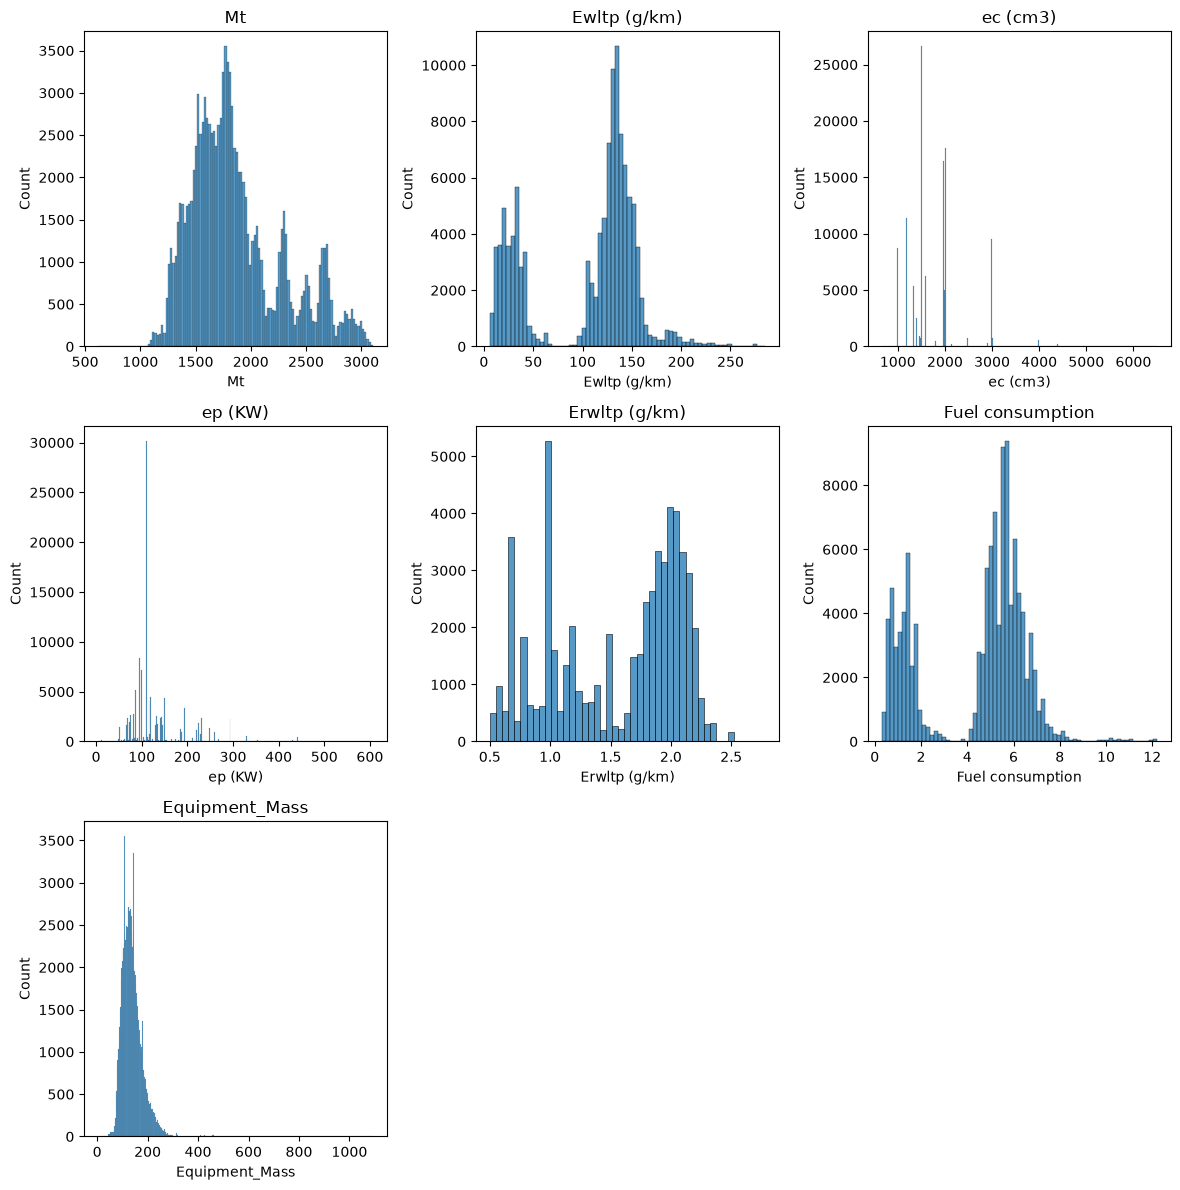

In [18]:
dist_graphs()

Now we need to split train and test so that we can implement standardization

In [19]:
display(df_2024.describe())
display(df_2024.info())

,Mt,Ewltp (g/km),ec (cm3),ep (KW),Erwltp (g/km),Fuel consumption,Equipment_Mass,IT_28,IT_29,IT_32,IT_33,IT_37,IT_none
count,114609.000000,114609.00000,114609.000000,114609.000000,59329.000000,114609.000000,114609.000000,114609.000000,114609.000000,114609.000000,114609.000000,114609.000000,114609.000000
mean,1867.103857,104.49449,1758.133611,130.266611,1.550224,4.402417,138.935773,0.021168,0.329512,0.065222,0.028061,0.401557,0.482336
std,418.597278,54.00122,558.301091,60.548684,0.526505,2.240821,45.004678,0.143944,0.470038,0.246918,0.165147,0.490215,0.499690
min,616.000000,6.00000,658.000000,4.000000,0.500000,0.300000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1567.000000,38.00000,1461.000000,96.000000,1.000000,1.700000,109.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1778.000000,128.00000,1598.000000,110.000000,1.760000,5.300000,132.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2066.000000,141.00000,1993.000000,145.000000,2.000000,5.900000,159.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,3108.000000,285.00000,6498.000000,607.000000,2.780000,12.200000,1094.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<class 'pandas.DataFrame'>
Index: 114609 entries, 0 to 119379
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Vehicle           114609 non-null  str    
 1   Mt                114609 non-null  float64
 2   Ewltp (g/km)      114609 non-null  float64
 3   Ft                114609 non-null  str    
 4   Fm                114609 non-null  str    
 5   ec (cm3)          114609 non-null  float64
 6   ep (KW)           114609 non-null  float64
 7   Erwltp (g/km)     59329 non-null   float64
 8   Fuel consumption  114609 non-null  float64
 9   Equipment_Mass    114609 non-null  float64
 10  IT_28             114609 non-null  int64  
 11  IT_29             114609 non-null  int64  
 12  IT_32             114609 non-null  int64  
 13  IT_33             114609 non-null  int64  
 14  IT_37             114609 non-null  int64  
 15  IT_none           114609 non-null  int64  
dtypes: float64(7), int64(6), str(3)
memo

None

In [20]:
df_2024.to_csv("../data/processed/EU/2024_FR_cleaned2.csv", index = False)